In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
import numpy as np
from rdkit.Chem.Draw import IPythonConsole
import json
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, rdFMCS
from typing import Callable
# import psiresp
# import nglview as nv
import MDAnalysis as mda
import glob
import re
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, clear_output
sys.path.append(os.path.abspath("../../espaloma-charge_mod/"))
sys.path.append(os.path.abspath('../')) 
import param_tool as pt
from espaloma_charge import charge

IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (600, 400)

In [2]:
!pwd

/trinity/home/_shared/_projects/2022_md_FRET_nv/AI_param_tool/notebooks_and_examples/AF_647_cys


# Протокол расчета парциальных зарядов для модифицированных аминокислот
На вход подаються .smi-файлы мономера и полимеров аминокислоты, где аминокислота входит в состав полимера в положениях N M C. 
У мономера должны бать группы COO<sup>-</sup> и N<sup>+</sup>H<sub>3</sub>. У полимеров соответствующие группы на С и N концах.  

In [3]:
PTM_name = 'AF_647'
base_name = '647'

## Шаг 1 Открытие .smi-файлов 
Мы рекомендуем использовать словари для записи фаилов молекул, также можно передать путь к  `.smi` в виде строки или листа. На выход вы получите словарь с соответствующими ключами. 

In [6]:
monomer_smi = pt.read_file(f'molecules/AF_647.smiles')
# monomer_smi =mon_name.read_file('moleculse/R_CIT.smiles')
trimers_smi = pt.read_file([
                            f'molecules/ACA_AF_647.smiles', 
                            # 'moleculse/GRG_CIT.smiles',
                            # 'moleculse/GR_CIT.smiles',

                           ],)
monomer_chem = pt.smi_to_chem(monomer_smi) # RDKit читает smi строку, переводит в chem и добавляет протоны
trimers_chem = pt.smi_to_chem(trimers_smi)
trimers_chem

{'ACA_AF_647': <rdkit.Chem.rdchem.Mol at 0x1553ec187df0>}

In [7]:
# os.path.basename('moleculse/AKA_1M.smiles').split('.')[0]
mon_name = str(*monomer_smi.keys())
pol_name = str(*trimers_smi.keys())
print(mon_name, pol_name, sep='\n')

AF_647
ACA_AF_647


## Шаг 2 Поиск подструктур мономера а.к. в полмерах
Наша задача выделить те атомы в составе полимеров, которые входят в состав мономера. Для этого функция `match_mon_to_pol` принимает на вход пару словарей с `Chem` фаилами. Словарь мономеров (один мономер) и полимеров (от 1 до ∞) соответственно. На выход подается словарь с ключами: `substructure`, `mon_pol_matches`, `N_match_atoms`, для кажого из полимеров. \
Где:
- `substructure` - сожердит общие подструктуры мономера и полимера, для каждого из полимеров в формате Chem .
- `mon_pol_matches` - содержит словари соответствия номеров атомов в общей подструктуре с номерами атомов в полимере молекула из общей подструктуры.
- `N_match_atoms` - количество общих атомов для мономера и полимера.\ 
(обычно вам не понадобится этот ключ, но он используется для подсвечивания общей структуры полимера на мономере)

Обратите внимание что набор атомов подструктур внутри мономера различается в зависимости от расположения а.к. в полимере

In [8]:
match_dict = pt.match_mon_to_pol(monomer_chem, trimers_chem, compare_any_bond = False)
# match_dict
print(match_dict.keys(),match_dict['substructure'], sep='\n')

Выполнение Поиск подструктуры между молекулами.  
Поиск подструктуры между молекулами выполнен успешно!
dict_keys(['substructure', 'substructure_noH', 'mon_pol_matches', 'N_match_atoms', 'mon_pol_atom_names'])
{'AF_647': <rdkit.Chem.rdchem.Mol object at 0x1553ec09c820>}


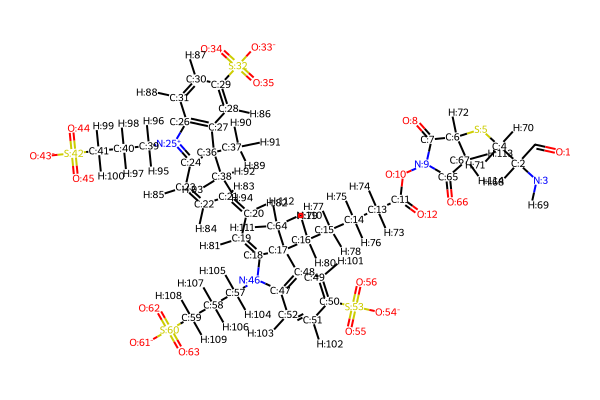

In [9]:
pt.draw_mol_with_atom_index(match_dict['substructure'][mon_name])

### Отрисовка полученных подструктур на молекулах мономера и полимера
Позволяет убедится в корректности структур

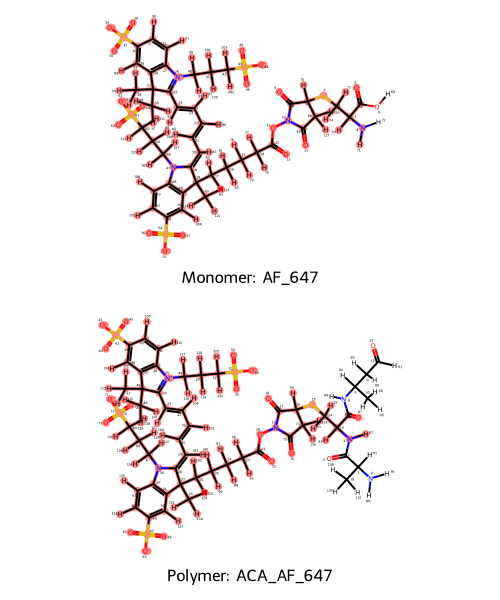

In [10]:
pt.draw_mon_pol_match(monomer_chem, trimers_chem, match_dict, add_small_atom_index=True, prefer_coord_gfen= False)

## Шаг 3 Сохранение молекул подструктур для N M С позиций 

Из молекулы мономера были выделены структуры аминокислот для каждой из позиций `N` `M` `C`. Важно ответить, что при созранение подструктур идет переупордочивание атомов таким образом, что первым атомом в молекуле становится автом **N** в составе аминогруппы. Далее имено они будут использоваться при получении файлов топологии. \
Ниже представленно несколько вариантов сохранения подструктур, но в итоге будут использоватсья файлы формата `.pdb` 

Были получены молекулярные формулы параметризируемых остатков `match_dict['substructure']`. Именно они будут использоваться для получения фаилов топологии в следующем ноутбуке.

#### Сохранение подструктур в виде **smiles**

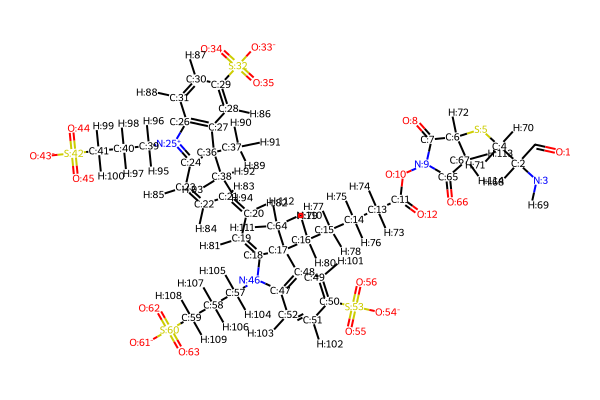

In [11]:
pt.draw_mol_with_atom_index(match_dict['substructure'][mon_name])

In [12]:
for chem_name, chem_mol in  match_dict['substructure'].items():
    print(chem_name, chem_mol)
    pt.save_aa_chem_to_smiles(chem_mol, f'molecules/substructure/{chem_name}',
                              canonical=False ,make_N_root=False)

AF_647 <rdkit.Chem.rdchem.Mol object at 0x1553ec09c820>
AF_647.smiles saved to molecules/substructure


##### Проверка сохраненных подструктур

In [14]:
test_smi = pt.read_file([f'molecules/substructure/{mon_name}.smiles',
                        ])
test_chem = pt.smi_to_chem(test_smi, addH=False, sanitize=False)
IPythonConsole.drawOptions.addAtomIndices = False

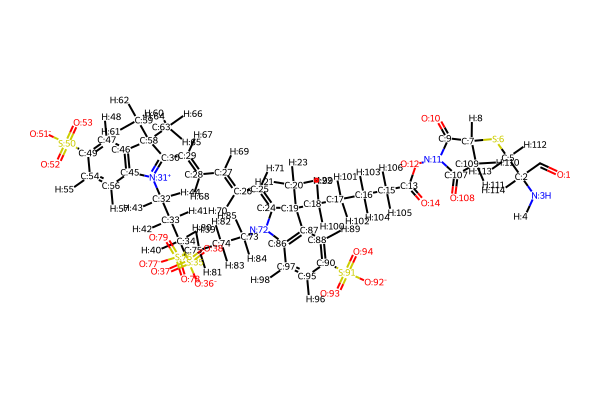

In [15]:
pt.draw_mol_with_atom_index(test_chem[mon_name])

### Сохранение подструктур в виде mol

In [30]:
list_N = []
for sub in match_dict['substructure'].values():
    N_index = pt.find_amino_nitrogen(sub)
    list_N.append(N_index)
print(list_N)
sub_name = ['NR_CIT', 'R_CIT', 'CR_CIT']
for chem_name, chem_mol, root in zip(sub_name, match_dict['substructure'].values(), list_N):
    pt.save_chem_to_mol(chem_mol, f'moleculse/substructure/{chem_name}', rootedAtAtom = root)
    print(chem_name, chem_mol)

10
10
11
[10, 10, 11]
NR_CIT <rdkit.Chem.rdchem.Mol object at 0x7f944627bee0>
R_CIT <rdkit.Chem.rdchem.Mol object at 0x7f944627bf40>
CR_CIT <rdkit.Chem.rdchem.Mol object at 0x7f9480340400>


In [53]:
mol_test = Chem.MolFromMolFile('moleculse/substructure/NR_CIT.mol', sanitize=False,removeHs=False)
# Chem.AddHs(mol_test)

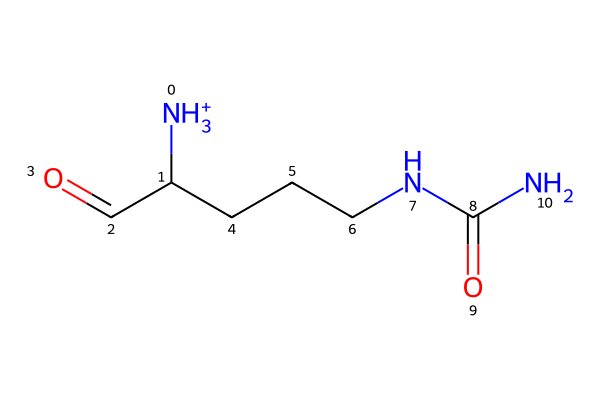

In [54]:
mol_test

In [41]:
IPythonConsole.drawOptions.addAtomIndices = True
mol_test

In [21]:
!pwd

/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT


### Сохранение подструктур в виде **pdb**

То как выглядит подструктура для одного из вариантов позиционирования остатка в цепи:

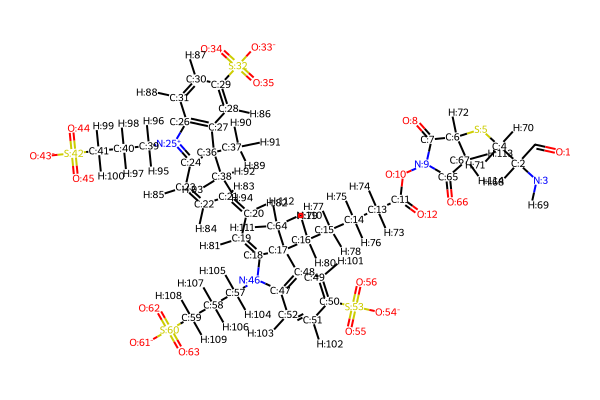

In [16]:
pt.draw_mol_with_atom_index(match_dict['substructure'][mon_name])

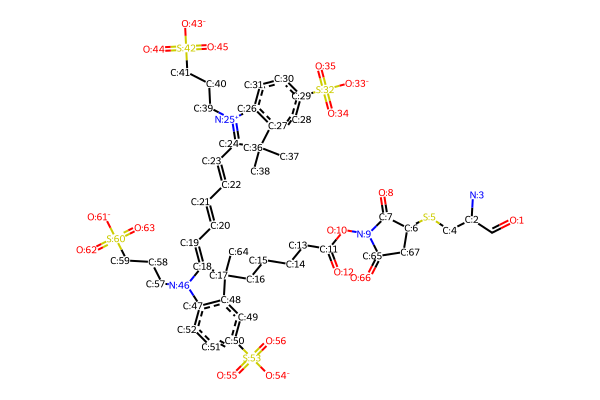

In [17]:
pt.draw_mol_with_atom_index(match_dict['substructure_noH'][mon_name])

In [18]:
new_mol_H = pt.renumber_amino_acid_atoms(match_dict['substructure'][mon_name])
new_mol_no_H = pt.renumber_amino_acid_atoms(match_dict['substructure_noH'][mon_name])

In [19]:
match_dict['substructure'][mon_name] = new_mol_H
match_dict['substructure_noH'][mon_name] = new_mol_no_H

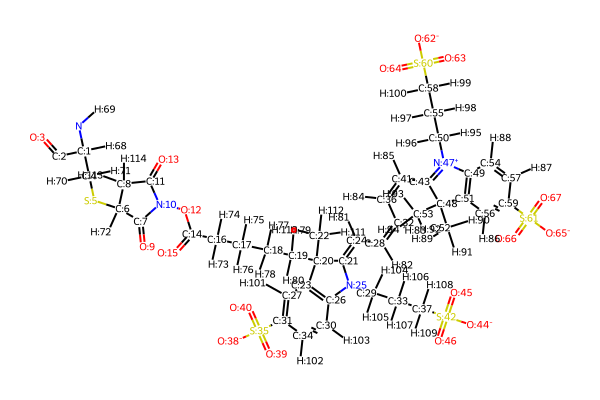

In [20]:
pt.draw_mol_with_atom_index(match_dict['substructure'][mon_name])

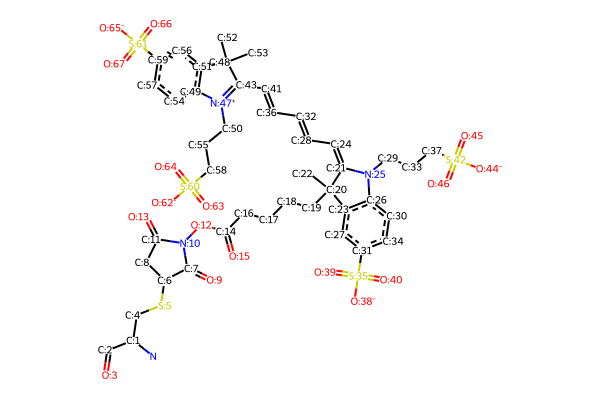

In [21]:
pt.draw_mol_with_atom_index(match_dict['substructure_noH'][mon_name])

Сохранение подструктуры (т.е. атомов входящих в состав модифицированного остатка в зависимости от его позиции в полимере) в формате 
`pdb`. \
Далее полученные ДНК используются для получения парциальных зарядов и для получения файлов топологии. \
Кроме этого вы можете взять их и использовать в молекулярном  моделировании для добавления модифицированного остатка в вашу структуру.   

##### Одиночное сохранение:
Мы сохраняем остаток ак в составе которго атомы только входящие в этот остаток. \
Все имен аатомов уникальные

In [22]:
pt.save_substructure_mol(match_dict, f'molecules/substructure', [mon_name],
                         resname = base_name, resid = 2, segid = 'A')

[13:16:39] Molecule does not have explicit Hs. Consider calling AddHs()
[13:16:40] Molecule does not have explicit Hs. Consider calling AddHs()



Уровень 1: 1 атомов
  Буква уровня: B
    CB (бывший) -> CB (индекс 1)
      водород HB1
      водород HB2

Уровень 2: 1 атомов
  Буква уровня: G
    SG (бывший) -> SG (индекс 1)

Уровень 3: 1 атомов
  Буква уровня: D
    CD (бывший) -> CD (индекс 1)
      водород HD

Уровень 4: 2 атомов
  Буква уровня: E
    CE (бывший) -> CE1 (индекс 1)
    CE (бывший) -> CE2 (индекс 2)
      водород HE21
      водород HE22

Уровень 5: 3 атомов
  Буква уровня: Z
    OZ (бывший) -> OZ1 (индекс 1)
    NZ (бывший) -> NZ2 (индекс 2)
    CZ (бывший) -> CZ3 (индекс 3)

Уровень 6: 2 атомов
  Буква уровня: H
    OH (бывший) -> OH1 (индекс 1)
    OH (бывший) -> OH2 (индекс 2)

Уровень 7: 1 атомов
  Буква уровня: T
    CT (бывший) -> CT (индекс 1)

Уровень 8: 2 атомов
  Буква уровня: I
    OI (бывший) -> OI1 (индекс 1)
    CI (бывший) -> CI2 (индекс 2)
      водород HI21
      водород HI22

Уровень 9: 1 атомов
  Буква уровня: K
    CK (бывший) -> CK (индекс 1)
      водород HK1
      водород HK2

Уровень 10: 

[13:16:40] Molecule does not have explicit Hs. Consider calling AddHs()
[13:16:42] Molecule does not have explicit Hs. Consider calling AddHs()


ValueError: Bad Conformer Id

##### Множественное сохранение:

In [10]:
sub_name = ['NR_CIT_1', 'R_CIT_1', 'CR_CIT_1']
resname_l = ['NRC', 'RC', 'CRC']
for chem_name, chem_mol, resname in zip(sub_name, match_dict['substructure'].values(), resname_l):
    pt.save_aa_chem_to_pdb(chem_mol, f'moleculse/substructure/{chem_name}_rdkit', resname = resname, make_N_root=True)

atom number: 0 became the root atom: 0
Длина atom_names_list не совпадает с количеством атомов в rdkit_mol. Будут использованы стандартные имена атомов.
NR_CIT_1_rdkit.pdb saved to moleculse/substructure


[13:16:38] Molecule does not have explicit Hs. Consider calling AddHs()
[13:16:38] Molecule does not have explicit Hs. Consider calling AddHs()


#### Проверка сохраненных молекул

In [23]:
if '_H' in mon_name:
    mon_name_no_H = mon_name.replace('_H','_no_H')
else:
    mon_name_no_H = mon_name + '_no_H'

In [25]:
# test_pdb = pt.pdb_to_chem(f'Lysine_Cro/molecules/substructure/Kcr_H2.pdb',
test_pdb = pt.pdb_to_chem([
            f'molecules/substructure/{mon_name}.pdb',
            # f'molecules/substructure/{mon_name_no_H}.pdb'
              # 'moleculse/substructure/CR_CIT.pdb'
                          ])
test_pdb

{'AF_647': <rdkit.Chem.rdchem.Mol at 0x1553eabb9690>}

Если все получилось, то вы молжны получить картинку тогоже остатка с такимиже типами связей и количеством атомов. \
В случае если вы использовали `make_N_root=True` последовательность нумерации атомов должна была поменяться и нулевым атомом должен был стать `N` в аминогруппе

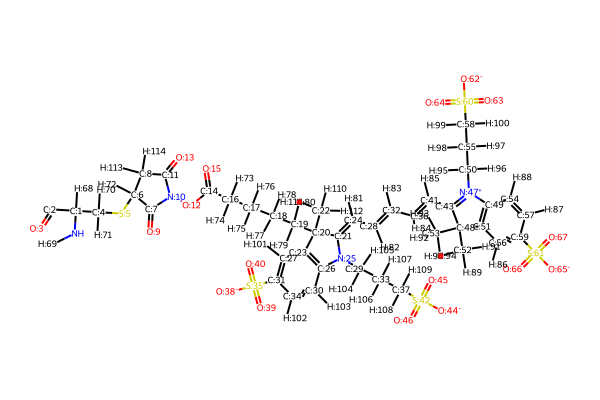

In [26]:
pt.draw_mol_with_atom_index(test_pdb[mon_name])

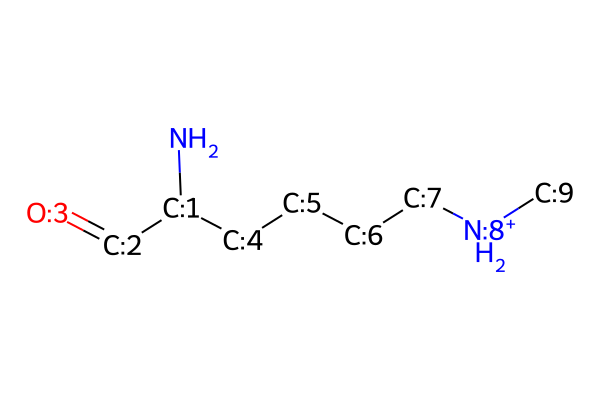

In [22]:
pt.draw_mol_with_atom_index(test_pdb[mon_name_no_H])

##### NGLview отрисовка

Поскольку мы сохранили pdb фаил то можно и через MDAnalysis и nglview посмотреть на него

In [71]:
nv.show_mdanalysis(mda.Universe(f'{PTM_name}/molecules/substructure/{mon_name}.pdb'))

NGLWidget()

## Шаг 4 Переименовка атомов в составе остатка с присвоением канонических имен к каноничным атомам  

Полученные на шаге 3 были полученые структуры остатков. Данные структуры имеют как канонические атомы (т.е. входят в состав каноничных аминокислоты), так и не канонические -- новые. \
На шаге 4 мы находим соствае парметризуемого остатка канонические атомы, которыек сохранилди ориганльные валентности и присваиваем им канонические имена атомов.

In [27]:
# PTM_name = 'Lysine_Cro'
# mon_name = 'Kcr_H'

print(mon_name, pol_name, sep='\n')

AF_647
ACA_AF_647


### Сопоставление модифицированного остатка с референсными остатками

In [29]:
path_to_mod_aa = f'molecules/substructure/{mon_name}.pdb'

mod_aa_name = os.path.basename(path_to_mod_aa).split('.')[0]
print(mod_aa_name)
mod_aa_chem_dict = pt.pdb_to_chem(path_to_mod_aa)

ref_aa_chem_dict, match_data_dict = pt.find_ref_aa(mod_aa_chem_dict, 
                             path_to_ref_mol='../molecules/aminoacids_template',
                             ref_base_name = 'C', only_heavy_mapping = False,
                             match_residue_number = 2, 
                             main_match_data=True, timeout=3)   
ref_aa_chem_dict, match_data_dict

AF_647
Производится сопоставление с Cys
Выполнение Поиск подструктуры между молекулами.  

/trinity/home/_shared/_projects/2022_md_FRET_nv/AI_param_tool/notebooks_and_examples/param_tool.py:769: UserWarning: ⚠ MCS с явными протонами может быть очень медленным.
  warnings.warn("⚠ MCS с явными протонами может быть очень медленным.")



Поиск подструктуры между молекулами выполнен успешно!
../molecules/aminoacids_template/GCG_H.pdb
Reference amino acid is GCG_H, with 10 matched atoms.


({'GCG_H': <rdkit.Chem.rdchem.Mol at 0x1553eabbab20>},
 {'substructure': {'GCG_H': <rdkit.Chem.rdchem.Mol at 0x1553eabbaa40>},
  'N_match_atoms': {'GCG_H': 10},
  'mon_pol_matches': {'GCG_H': {69: 10,
    0: 9,
    1: 11,
    68: 12,
    4: 13,
    2: 18,
    70: 14,
    71: 15,
    5: 16,
    3: 19}},
  'mon_pol_atom_names': {'GCG_H': {'H': 'H',
    'N': 'N',
    'CA': 'CA',
    'HA': 'HA',
    'CB': 'CB',
    'C': 'C',
    'HB1': 'HB1',
    'HB2': 'HB2',
    'SG': 'SG',
    'O': 'O'}}})

In [25]:
# match_data_dict

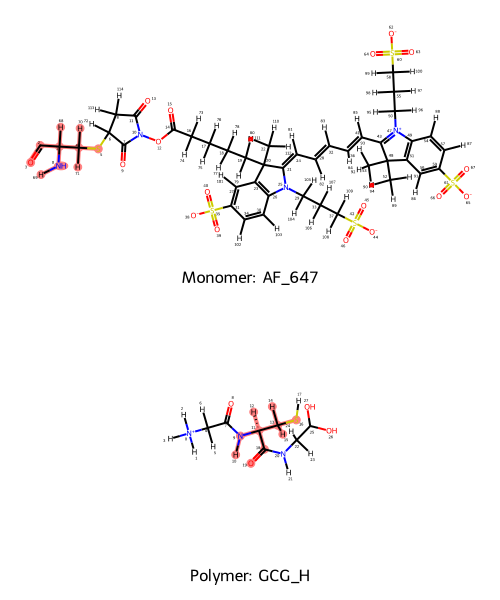

In [30]:
pt.draw_mon_pol_match(mod_aa_chem_dict, ref_aa_chem_dict, match_data_dict, 
                      add_small_atom_index=True, prefer_coord_gfen = False)

In [50]:
pt.save_json('general_atoms', list(*match_data_dict['mon_pol_atom_names'].values()), )

Файл успешно сохранен: 
/trinity/home/_shared/_projects/2022_md_FRET_nv/AI_param_tool/notebooks_and_examples/AF_647_cys/general_atoms.json


### Переименовка атомов в модифицированном остатке

In [31]:
key_map = next(iter(match_data_dict['mon_pol_matches'].keys()))
match_data_dict['mon_pol_matches'][key_map]

{69: 10, 0: 9, 1: 11, 68: 12, 4: 13, 2: 18, 70: 14, 71: 15, 5: 16, 3: 19}

In [32]:
modifie_residue = pt.add_names_from_residue(mod_aa_chem_dict,
                       match_data_dict,
                        resid = 2,
                        resname = base_name,)

Дубликаты имен атомов не найдены.


In [33]:
save_molecule_as_pdb(modifie_residue, f'molecules/substructure/{PTM_name}_rn.pdb', format_coord='3D')

NameError: name 'save_molecule_as_pdb' is not defined

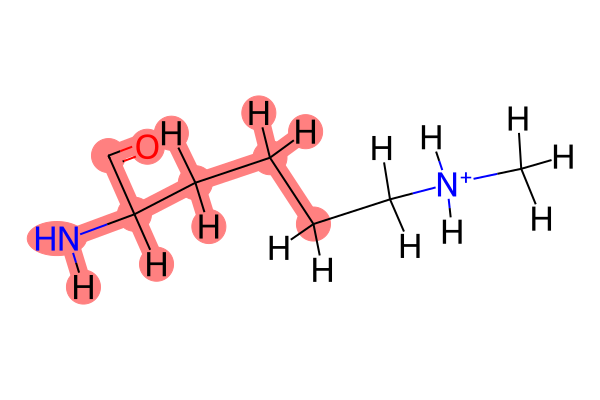

In [32]:
modifie_residue

### Шаг 4.1. Протонирование атомов, потерявших стандартную валентность 

Этот шаг необходим для дальнейшего получения файла itp для нашей а.к. \
Дело в том, что acpype отказывается создавать топологию для атомов с нестандартными валентностями, что вполне логично. Поэтому мы добавляем протоны, которых на самом деле нет в остатке. После в процесе редактирвоания itp мы удалим все строки с лишними протонами. \
Стоит отметить, что этот шаг можно также выполнить с использованием любого удобного вам молекулярного редактора (ChimeraX, PyMOL) взяв за основу pdb фаийл сохраненный на 3-ем шаге.

In [35]:
H_modifie_residue = pt.add_protons_and_renumber_H(modifie_residue, resname = base_name, resid=2, segid='A')

Для атома 115 присвоено имя HW1
Для атома 116 присвоено имя HW2


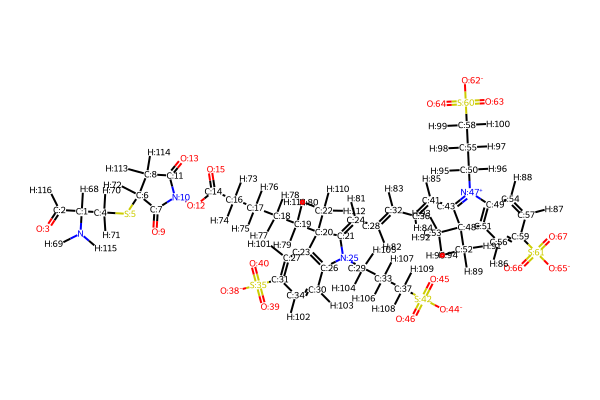

In [36]:
pt.draw_mol_with_atom_index(H_modifie_residue)

In [37]:
for atom in H_modifie_residue.GetAtoms():
    info = atom.GetPDBResidueInfo()
    print(info.GetResidueNumber(), info.GetResidueName(), atom.GetProp('AtomName'), atom.GetIdx(), atom.GetAtomMapNum())

2 647 N 0 0
2 647 CA 1 1
2 647 C 2 2
2 647 O 3 3
2 647 CB 4 4
2 647 SG 5 5
2 647 CD 6 6
2 647 CE1 7 7
2 647 CE2 8 8
2 647 OZ1 9 9
2 647 NZ2 10 10
2 647 CZ3 11 11
2 647 OH1 12 12
2 647 OH2 13 13
2 647 CT 14 14
2 647 OI1 15 15
2 647 CI2 16 16
2 647 CK 17 17
2 647 C19 18 18
2 647 C20 19 19
2 647 C21 20 20
2 647 C22 21 21
2 647 C23 22 22
2 647 C24 23 23
2 647 C25 24 24
2 647 N26 25 25
2 647 C27 26 26
2 647 C28 27 27
2 647 C29 28 28
2 647 C30 29 29
2 647 C31 30 30
2 647 C32 31 31
2 647 C33 32 32
2 647 C34 33 33
2 647 C35 34 34
2 647 S36 35 35
2 647 C37 36 36
2 647 C38 37 37
2 647 O39 38 38
2 647 O40 39 39
2 647 O41 40 40
2 647 C42 41 41
2 647 S43 42 42
2 647 C44 43 43
2 647 O45 44 44
2 647 O46 45 45
2 647 O47 46 46
2 647 N48 47 47
2 647 C49 48 48
2 647 C50 49 49
2 647 C51 50 50
2 647 C52 51 51
2 647 C53 52 52
2 647 C54 53 53
2 647 C55 54 54
2 647 C56 55 55
2 647 C57 56 56
2 647 C58 57 57
2 647 C59 58 58
2 647 C60 59 59
2 647 S61 60 60
2 647 S62 61 61
2 647 O63 62 62
2 647 O64 63 63
2 647 O6

In [38]:
pt.save_molecule_as_pdb(H_modifie_residue, f'molecules/substructure/{PTM_name}_rn_H.pdb', format_coord='3D')

Молекула успешно сохранена в файле molecules/substructure/AF_647_rn_H_3D.pdb в формате 3D.


In [39]:
pt.save_aa_chem_to_smiles(H_modifie_residue, f'molecules/substructure/{chem_name}_rn_H.smiles', canonical=False ,make_N_root=False)

AF_647_rn_Hles.smiles saved to molecules/substructure


In [37]:
test = mda.Universe(f'{PTM_name}/molecules/substructure/{PTM_name}_rn_H_3D.pdb')
nv.show_mdanalysis(test)

NGLWidget()

## Шаг 5. Расчет зарядов при помощи библиотеки Espaloma Charge

На вход: 
- Молекула-ы в виде тримеров в формате smiles. 

Задача ограничейни зарядов для одной молекулы


Создание ограничений

In [40]:
!pwd

/trinity/home/_shared/_projects/2022_md_FRET_nv/AI_param_tool/notebooks_and_examples/AF_647_cys


In [41]:
PTM_name

'AF_647'

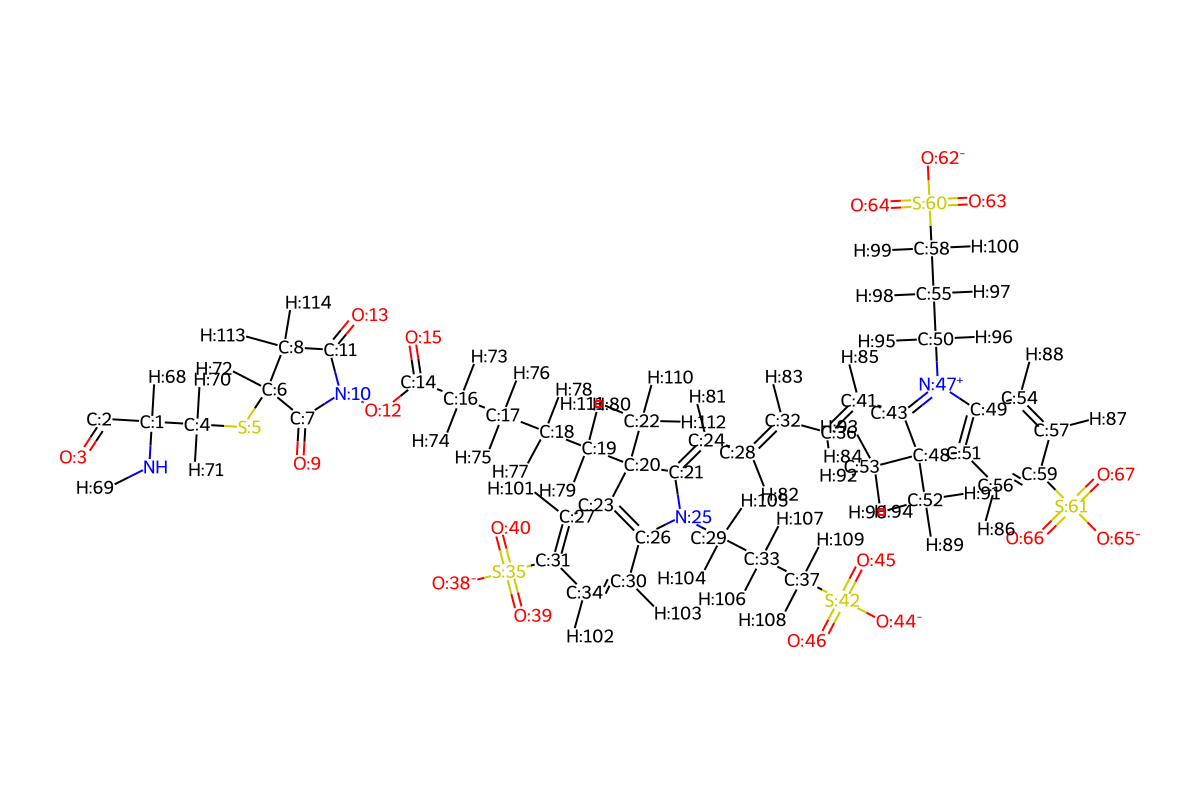

In [45]:
residue = pt.pdb_to_chem(f'molecules/substructure/{mon_name}.pdb')
pt.draw_mol_with_atom_index(residue[mon_name], size = (1200,800))

In [46]:
constraint_dict = {f'{mon_name}':
                  {'symmetric_list': [],
                   'charge_atom_dict': {0:-0.41570, 69:0.27190, 
                                        1:0.02130, 2:0.59730, 
                                        3:-0.56790, 68:0.11240},
                   'charge_of_monomer': -3.0000,
                  }
                  }

### Расчет зарядов при помощи библиотеки Espaloma Charge

In [47]:
charges = charge(residue[mon_name], 
                 constraints=constraint_dict[mon_name]['charge_atom_dict']
                )

print(f'Суммарный заряд молекулы: {sum(charges)}', charges, sep = '\n')


/trinity/home/n_kristovsky/.conda/envs/darwin_ec/lib/python3.12/site-packages/dgl/heterograph.py:92: DGLWarning: Recommend creating graphs by `dgl.graph(data)` instead of `dgl.DGLGraph(data)`.
  dgl_warning(


Суммарный заряд молекулы: -2.9999991673976183
[-0.4157      0.0213      0.5973     -0.5679     -0.21286836  0.45211315
 -0.1386238   0.50280213 -0.28814617 -0.4190331  -0.3379406   0.49683106
 -0.07615924 -0.41445303  0.41876945 -0.5589929  -0.23717274 -0.20242923
 -0.2030341  -0.18736234  0.03680131 -0.2281993  -0.33717856 -0.31990698
 -0.18547466 -0.32790825 -0.10203762 -0.19484723 -0.46352956  0.02945908
 -0.39583164 -0.24142157 -0.44572133 -0.04148839 -0.27272993  1.6033833
 -0.39205223 -0.55252343 -0.6405486  -0.7302408  -0.7302408  -0.20357925
  1.6186408  -0.20805736 -0.5017426  -0.6686445  -0.6686445  -0.19925636
  0.02460396 -0.11985005 -0.15446696 -0.26369548 -0.3634239  -0.3634239
 -0.33336255 -0.02579153 -0.17760175 -0.27776685 -0.56314874 -0.23582767
  1.6156808   1.6033833  -0.5017426  -0.6686445  -0.6686445  -0.6405485
 -0.7302408  -0.7302408   0.1124      0.2719      0.13996325  0.13996324
  0.2148253   0.16113178  0.16113178  0.1413434   0.1413434   0.13876377
  0.1387

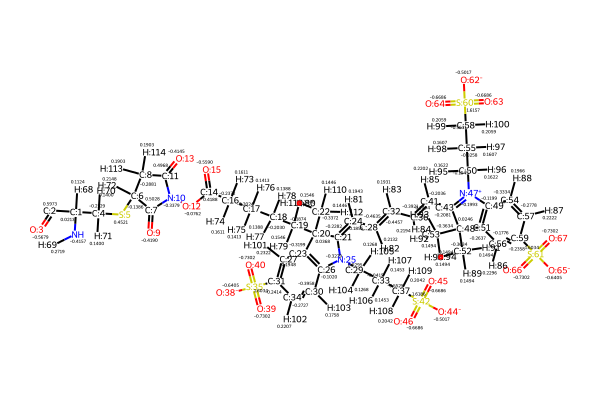

In [48]:
pt.draw_mol_with_atom_index(residue[mon_name], charge_list=charges)

## Сохранение масcива зарядов

In [49]:
pt.save_charges_json(name = f'AI_chrges_{mon_name}', charge_list = charges.tolist(),  )

Файл успешно сохранен: 
/trinity/home/_shared/_projects/2022_md_FRET_nv/AI_param_tool/notebooks_and_examples/AF_647_cys/AI_chrges_AF_647.json
